In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
crop=pd.read_csv(r"C:\Users\naren\Desktop\Projects\NilamGuru\Dataset\Crop_recommendation.csv")

In [3]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
crop.shape

(2200, 8)

In [5]:
crop.duplicated().sum()

np.int64(0)

In [6]:
crop.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

In [7]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
crop['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

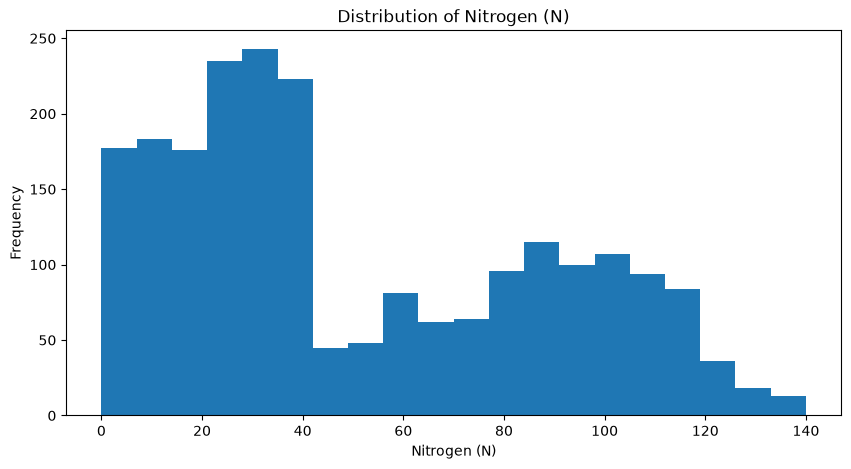

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(crop["N"], bins=20)
plt.xlabel("Nitrogen (N)")
plt.ylabel("Frequency")
plt.title("Distribution of Nitrogen (N)")
plt.show()

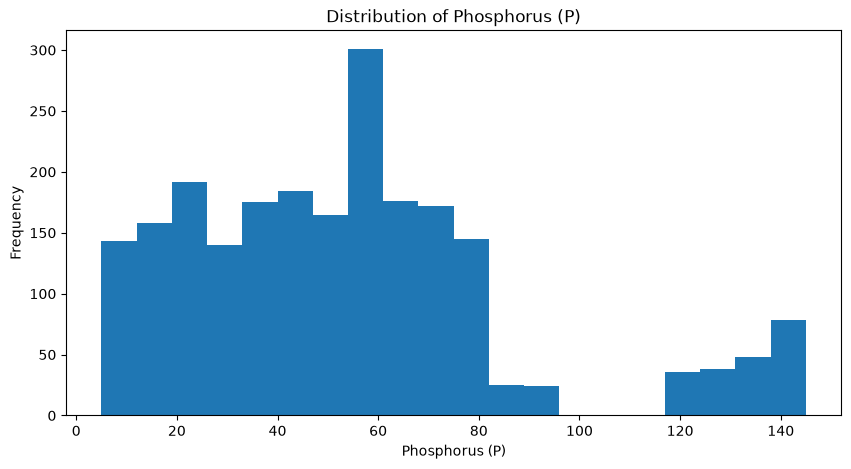

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(crop["P"], bins=20)
plt.xlabel("Phosphorus (P)")
plt.ylabel("Frequency")
plt.title("Distribution of Phosphorus (P)")
plt.show()

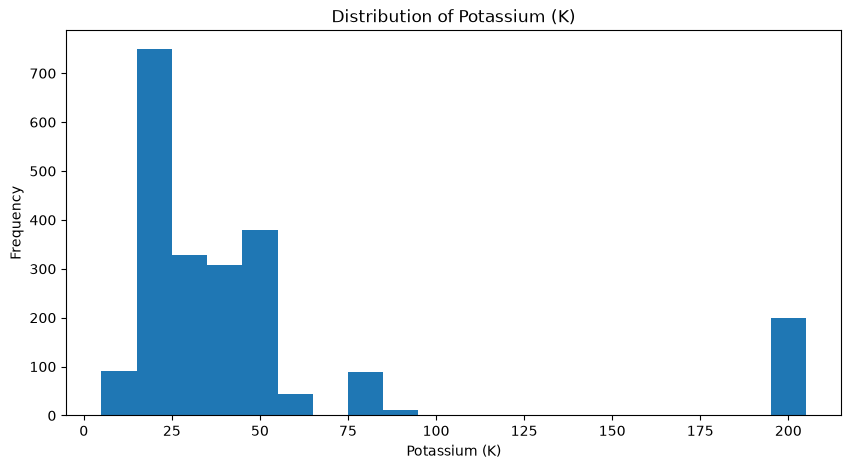

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(crop["K"], bins=20)
plt.xlabel("Potassium (K)")
plt.ylabel("Frequency")
plt.title("Distribution of Potassium (K)")
plt.show()

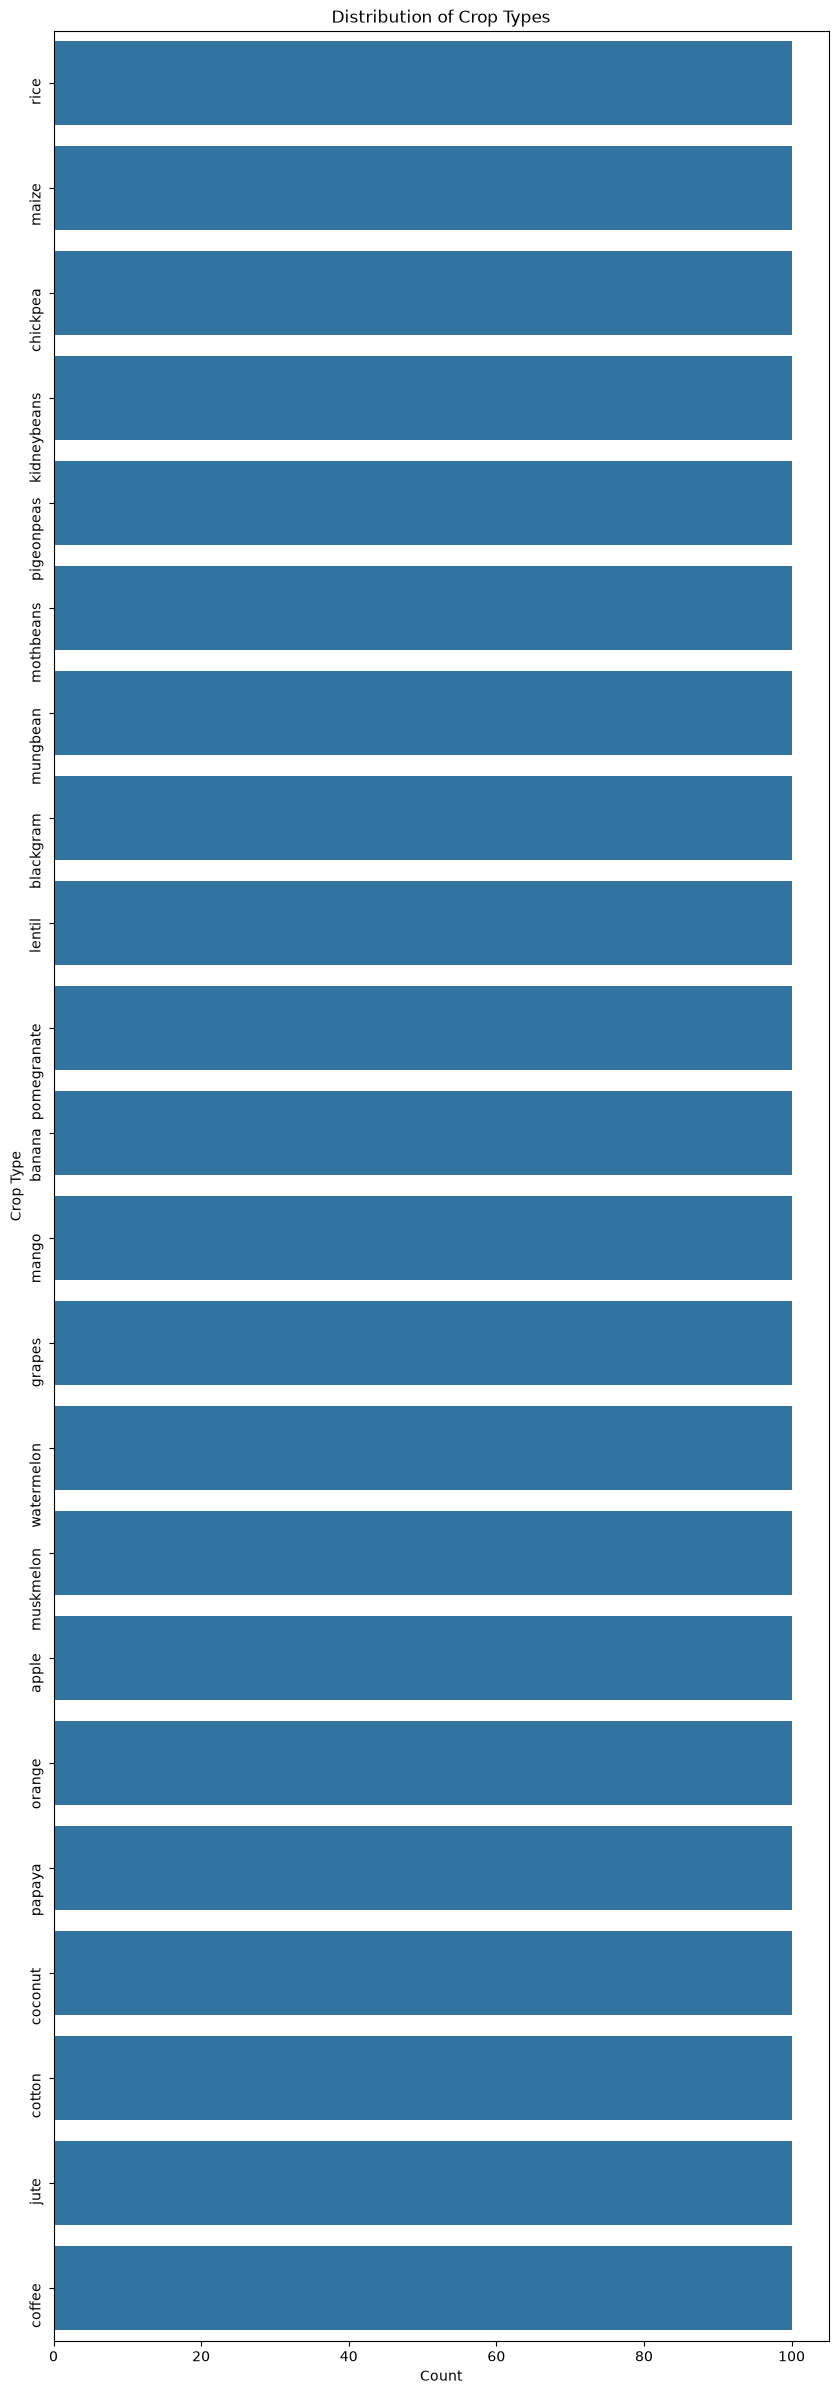

In [12]:
plt.figure(figsize=(10, 30))
sns.barplot(y=crop['label'].value_counts().index, x=crop['label'].value_counts())
plt.yticks(rotation=90)
plt.xlabel("Count")
plt.ylabel("Crop Type")
plt.title("Distribution of Crop Types")
plt.show()

In [13]:
LabelEncoder = LabelEncoder()
crop['label'] = LabelEncoder.fit_transform(crop['label'])

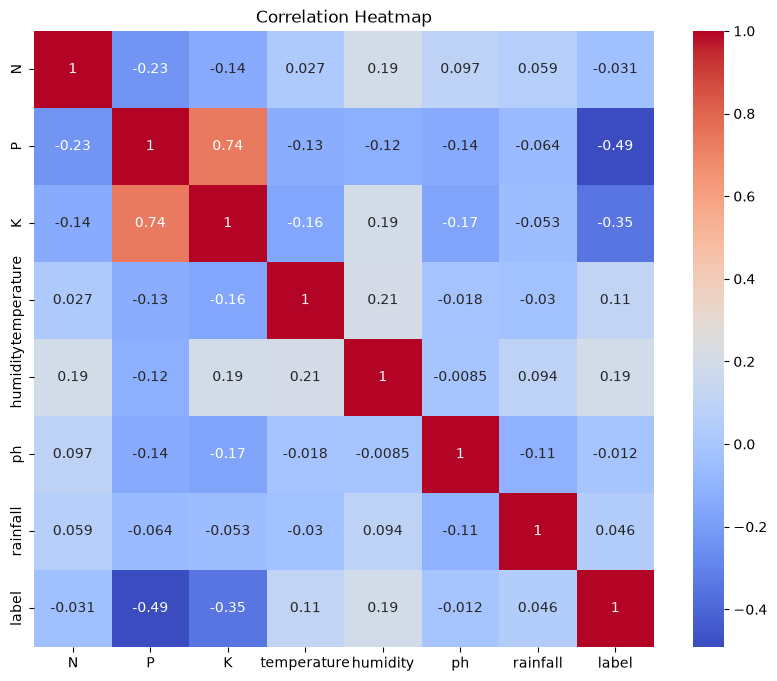

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(crop.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
features = crop.drop('label', axis=1)
target = crop['label']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [17]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)


# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

In [18]:
rf_accuracy = accuracy_score(y_test, rf_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

rf_precision = precision_score(y_test, rf_pred, average="weighted")
xgb_precision = precision_score(y_test, xgb_pred, average="weighted")

rf_recall = recall_score(y_test, rf_pred, average="weighted")
xgb_recall = recall_score(y_test, xgb_pred, average="weighted")

rf_f1 = f1_score(y_test, rf_pred, average="weighted")
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")


results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "Precision": [rf_precision, xgb_precision],
    "Recall": [rf_recall, xgb_recall],
    "F1 Score": [rf_f1, xgb_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.993182,0.993735,0.993182,0.993175
1,XGBoost,0.986364,0.987265,0.986364,0.986316


In [19]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best CV Score:
0.9948775951412957


In [20]:
model= RandomForestClassifier( n_estimators=200,
                              max_depth=None,
                                min_samples_split=2,
                                min_samples_leaf=1,
                                max_features='sqrt',
                                random_state=42
                            )       

In [21]:
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [22]:
pre_train=model.predict(x_train)
acc_train=accuracy_score(y_train, pre_train)
print(f"Training Accuracy: {acc_train:.4f}")

Training Accuracy: 1.0000


In [23]:
pre_test=model.predict(x_test)
acc_test=accuracy_score(y_test, pre_test)
print(f"Testing Accuracy: {acc_test:.4f}")

Testing Accuracy: 0.9932


In [24]:
confusion = confusion_matrix(y_test, pre_test)


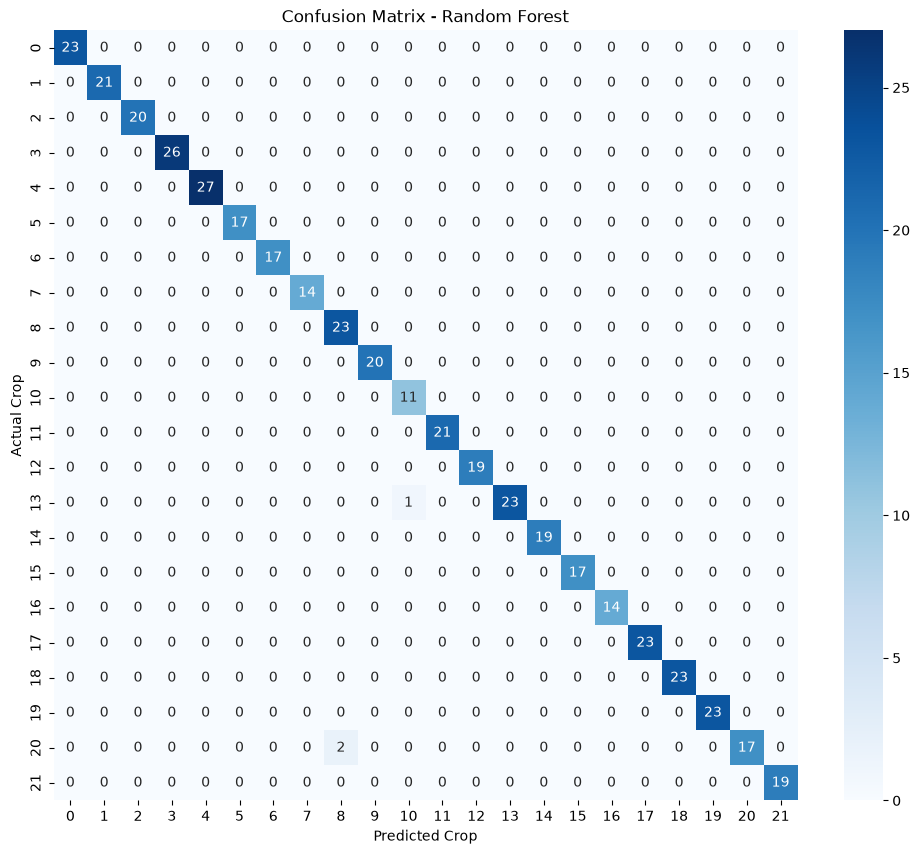

In [25]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [26]:
import joblib

In [27]:
joblib.dump(model, 'crop_recommendation_model.pkl')

['crop_recommendation_model.pkl']

In [28]:
model = joblib.load("C:\\Users\\naren\\Desktop\\Projects\\NilamGuru\\models\\crop_recommendation_model.pkl")

prediction = model.predict(x_test)

print(prediction[:10])

[15 21 17 17  0 12  0 13 14 10]


In [29]:
joblib.dump(LabelEncoder, "crop_label_encoder.pkl")

['crop_label_encoder.pkl']